In [1]:
# ViT-Tiny improved + D4 symmetry augmentation during training.
# Train with random 90/180/270 rotation + horizontal/vertical flips + color jitter.
# Test on 0/90/180/270 to see if augmentation closes the rotation gap.

import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

DATA_DIR = r"E:\Deep Learning Spring 26\dataset"
BATCH_SIZE = 32
EPOCHS = 6
LR = 1e-4
NUM_WORKERS = 0
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
train_dir = os.path.join(DATA_DIR, "train")
df = pd.read_csv(os.path.join(DATA_DIR, "train_labels.csv"))

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df.label, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df.label, random_state=SEED)
print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 176020  |  Val: 22002  |  Test: 22003


In [3]:
# D4 symmetry augmentation: random 90-degree rotations + flips + color jitter.
# This covers all 8 symmetries of the square (the dihedral group D4).
# Each image has equal chance of being rotated 0/90/180/270 and flipped H/V.
train_transform = transforms.Compose([
    transforms.RandomChoice([
        transforms.Lambda(lambda img: img),
        transforms.Lambda(lambda img: img.rotate(90)),
        transforms.Lambda(lambda img: img.rotate(180)),
        transforms.Lambda(lambda img: img.rotate(270)),
    ]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class CancerDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, rotation=0):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.rotation = rotation
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row.id + ".tif")).convert("RGB")
        if self.rotation != 0:
            img = img.rotate(self.rotation)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row.label, dtype=torch.float32)

In [4]:
train_loader = DataLoader(CancerDataset(train_df, train_dir, train_transform, rotation=0),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(CancerDataset(val_df, train_dir, eval_transform, rotation=0),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

test_loaders = {}
for angle in [0, 90, 180, 270]:
    test_loaders[angle] = DataLoader(
        CancerDataset(test_df, train_dir, eval_transform, rotation=angle),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [5]:
# load ViT-Tiny and remove the default head
model = timm.create_model("vit_tiny_patch16_224", pretrained=True, num_classes=0, img_size=96)

# freeze everything, then selectively unfreeze last 2 blocks + norm
for param in model.parameters():
    param.requires_grad = False
for name, param in model.named_parameters():
    if "blocks.10" in name or "blocks.11" in name or "norm" in name:
        param.requires_grad = True

# custom head: 192 -> 128 -> 1
model.head = nn.Sequential(
    nn.Linear(192, 128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 1))
model = model.to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {num_params:,}")

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

Trainable params: 922,625


In [6]:
def train_one_epoch():
    model.train()
    total_loss = 0
    preds_list, labels_list = [], []
    for imgs, labels in tqdm(train_loader, desc="Training", leave=False):
        imgs = imgs.to(device)
        labels = labels.unsqueeze(1).to(device)
        out = model(imgs)
        loss = criterion(out, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds_list.extend(torch.sigmoid(out).squeeze().detach().cpu().numpy())
        labels_list.extend(labels.squeeze().cpu().numpy())
    avg_loss = total_loss / len(train_loader)
    p, l = np.array(preds_list), np.array(labels_list).astype(int)
    b = (p >= 0.5).astype(int)
    return avg_loss, accuracy_score(l, b), f1_score(l, b, average="weighted"), roc_auc_score(l, p)

def evaluate(loader):
    model.eval()
    preds_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds_list.extend(torch.sigmoid(model(imgs)).squeeze().cpu().numpy())
            labels_list.extend(labels.numpy())
    p, l = np.array(preds_list), np.array(labels_list).astype(int)
    b = (p >= 0.5).astype(int)
    return accuracy_score(l, b), f1_score(l, b, average="weighted"), roc_auc_score(l, p)

In [7]:
best_auc = 0.0
for epoch in range(1, EPOCHS + 1):
    loss, train_acc, train_f1, train_auc = train_one_epoch()
    scheduler.step()
    val_acc, val_f1, val_auc = evaluate(val_loader)

    lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch}/{EPOCHS} (lr={lr:.2e})")
    print(f"  Train  =>  Loss: {loss:.4f}  Acc: {train_acc:.4f}  F1: {train_f1:.4f}  AUC: {train_auc:.4f}")
    print(f"  Val    =>  Acc: {val_acc:.4f}  F1: {val_f1:.4f}  AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        save_path = os.path.abspath("best_vit_d4.pth")
        torch.save(model.state_dict(), save_path)
        print(f"  >> Saved best model (AUC={val_auc:.4f}) at {save_path}")


Epoch 1/6 (lr=9.33e-05)
  Train  =>  Loss: 0.3556  Acc: 0.8431  F1: 0.8421  AUC: 0.9167
  Val    =>  Acc: 0.8792  F1: 0.8794  AUC: 0.9490
  >> Saved best model (AUC=0.9490) at e:\Deep Learning Spring 26\dataset\best_vit_d4.pth



Epoch 2/6 (lr=7.50e-05)
  Train  =>  Loss: 0.2908  Acc: 0.8784  F1: 0.8777  AUC: 0.9444
  Val    =>  Acc: 0.8943  F1: 0.8944  AUC: 0.9584
  >> Saved best model (AUC=0.9584) at e:\Deep Learning Spring 26\dataset\best_vit_d4.pth



Epoch 3/6 (lr=5.00e-05)
  Train  =>  Loss: 0.2620  Acc: 0.8926  F1: 0.8921  AUC: 0.9547
  Val    =>  Acc: 0.9042  F1: 0.9043  AUC: 0.9633
  >> Saved best model (AUC=0.9633) at e:\Deep Learning Spring 26\dataset\best_vit_d4.pth



Epoch 4/6 (lr=2.50e-05)
  Train  =>  Loss: 0.2388  Acc: 0.9027  F1: 0.9023  AUC: 0.9624
  Val    =>  Acc: 0.9129  F1: 0.9125  AUC: 0.9683
  >> Saved best model (AUC=0.9683) at e:\Deep Learning Spring 26\dataset\best_vit_d4.pth



Epoch 5/6 (lr=6.70e-06)
  Train  =>  Loss: 0.2239  Acc: 0.9102  F1: 0.9098  AUC: 0.9668
  Val    =>  Acc: 0.9200  F1: 0.9198  AUC: 0.9711
  >> Saved best model (AUC=0.9711) at e:\Deep Learning Spring 26\dataset\best_vit_d4.pth



Epoch 6/6 (lr=0.00e+00)
  Train  =>  Loss: 0.2135  Acc: 0.9153  F1: 0.9150  AUC: 0.9696
  Val    =>  Acc: 0.9193  F1: 0.9193  AUC: 0.9731
  >> Saved best model (AUC=0.9731) at e:\Deep Learning Spring 26\dataset\best_vit_d4.pth


In [8]:
print("\nRotation test (best model):")
model.load_state_dict(torch.load(os.path.abspath("best_vit_d4.pth"), weights_only=True))
for angle in [0, 90, 180, 270]:
    acc, f1, auc = evaluate(test_loaders[angle])
    print(f"  {angle:3d}°  =>  Acc: {acc:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")

## Confusion Matrix & Recall

Now let's look at the confusion matrix for the 0° test set. Recall is the most important metric here — in cancer detection, missing a true positive (low recall) is far more dangerous than a false alarm.

In [8]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# get predictions at 0°
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loaders[0], desc="Predicting", leave=False):
        imgs = imgs.to(device)
        probs = torch.sigmoid(model(imgs)).squeeze().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

probs_0 = np.array(all_probs)
labels = np.array(all_labels).astype(int)
preds_0 = (probs_0 >= 0.5).astype(int)

cm = confusion_matrix(labels, preds_0)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")
print()
print(f"Accuracy:  {accuracy_score(labels, preds_0):.4f}")
print(f"Recall:    {recall_score(labels, preds_0):.4f}")
print(f"Precision: {precision_score(labels, preds_0):.4f}")
print(f"F1:        {f1_score(labels, preds_0, average="weighted"):.4f}")
print(f"AUC:       {roc_auc_score(labels, probs_0):.4f}")

Confusion Matrix:
  TN=12111  FP=980
  FN=832  TP=8080

Accuracy:  0.9176
Recall:    0.9066
Precision: 0.8918
F1:        0.9178
AUC:       0.9734


Confusion matrix heatmap.

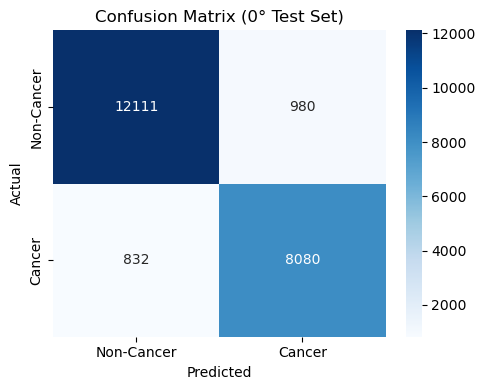

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Non-Cancer", "Cancer"],
            yticklabels=["Non-Cancer", "Cancer"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (0° Test Set)")
plt.tight_layout()
plt.show()

## Flip Rate Analysis

The flip rate measures how many diagnoses change when the same image is tested at a different rotation. For each test sample, we compare the 0° prediction to the rotated prediction. If they disagree, that's a flip.

A flip rate of 0% means perfectly rotation-invariant predictions. In a clinical setting, a patient should not get a different diagnosis just because the slide was oriented differently.

We also break down flips by direction:
- Cancer → Non-Cancer: the model caught it at 0° but missed it when rotated (dangerous)
- Non-Cancer → Cancer: the model missed it at 0° but flagged it when rotated

In [10]:
# collect predictions at each rotated angle
rotated_preds = {}
rotated_probs = {}

for angle in [90, 180, 270]:
    all_probs, all_labels_r = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(test_loaders[angle], desc=f"{angle}°", leave=False):
            imgs = imgs.to(device)
            probs = torch.sigmoid(model(imgs)).squeeze().cpu().numpy()
            all_probs.extend(probs)
    rotated_probs[angle] = np.array(all_probs)
    rotated_preds[angle] = (rotated_probs[angle] >= 0.5).astype(int)

# compute flip rates
print("Flip Rate Analysis:")
print()
for angle in [90, 180, 270]:
    flipped = (preds_0 != rotated_preds[angle])
    flip_rate = flipped.mean() * 100
    cancer_to_non = ((preds_0 == 1) & (rotated_preds[angle] == 0)).sum()
    non_to_cancer = ((preds_0 == 0) & (rotated_preds[angle] == 1)).sum()

    print(f"  {angle:3d}°: {flipped.sum()} / {len(flipped)} flipped  =>  Flip Rate = {flip_rate:.2f}%")
    print(f"       Cancer->Non-Cancer: {cancer_to_non}   Non-Cancer->Cancer: {non_to_cancer}")

# average
flip_rates = []
for angle in [90, 180, 270]:
    flipped = (preds_0 != rotated_preds[angle])
    flip_rates.append(flipped.mean() * 100)
print(f" Average Flip Rate: {np.mean(flip_rates):.2f}%")

Flip Rate Analysis:

   90°: 1335 / 22003 flipped  =>  Flip Rate = 6.07%
       Cancer->Non-Cancer: 665   Non-Cancer->Cancer: 670
  180°: 1342 / 22003 flipped  =>  Flip Rate = 6.10%
       Cancer->Non-Cancer: 671   Non-Cancer->Cancer: 671
  270°: 1403 / 22003 flipped  =>  Flip Rate = 6.38%
       Cancer->Non-Cancer: 687   Non-Cancer->Cancer: 716
 Average Flip Rate: 6.18%


## Per-Angle Summary

Everything in one table: accuracy, recall, AUC, and flip rate for each angle.

In [11]:
print(f"{"Angle":>5s}  {"Acc":>7s}  {"Recall":>7s}  {"AUC":>7s}  {"Flip %":>7s}")
print(f"{"-----":>5s}  {"------":>7s}  {"------":>7s}  {"------":>7s}  {"------":>7s}")
print(f"{"0°":>5s}  {accuracy_score(labels, preds_0):7.4f}  {recall_score(labels, preds_0):7.4f}  {roc_auc_score(labels, probs_0):7.4f}  {"  ---":>7s}")

for angle in [90, 180, 270]:
    acc = accuracy_score(labels, rotated_preds[angle])
    rec = recall_score(labels, rotated_preds[angle])
    auc = roc_auc_score(labels, rotated_probs[angle])
    fr = ((preds_0 != rotated_preds[angle]).mean() * 100)
    print(f"{angle:>4d}°  {acc:7.4f}  {rec:7.4f}  {auc:7.4f}  {fr:6.2f}%")

Angle      Acc   Recall      AUC   Flip %
-----   ------   ------   ------   ------
   0°   0.9176   0.9066   0.9734      ---
  90°   0.9201   0.9100   0.9737    6.07%
 180°   0.9193   0.9087   0.9731    6.10%
 270°   0.9189   0.9098   0.9736    6.38%


## Visualizations

Flip rate, accuracy, and recall across rotation angles.

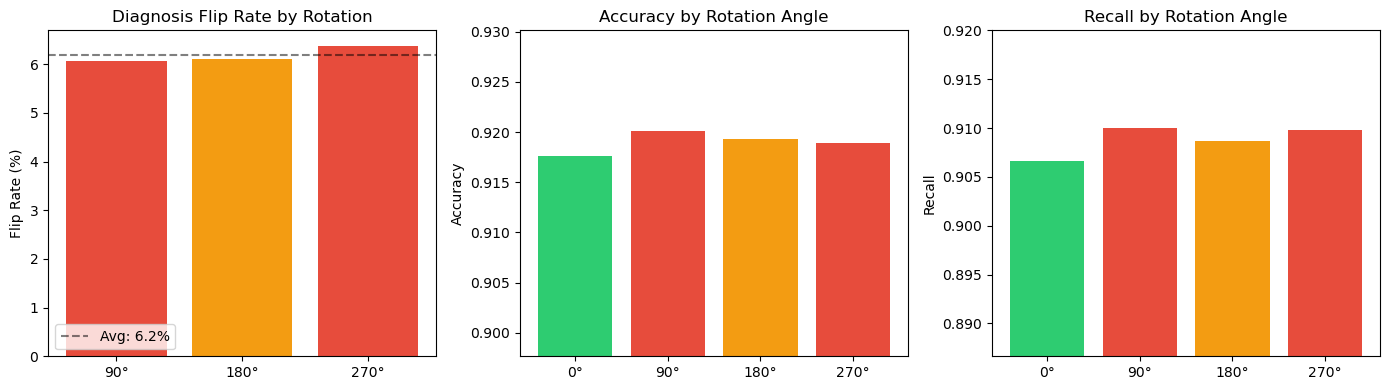

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

angles_list = [90, 180, 270]
fr_list = [((preds_0 != rotated_preds[a]).mean() * 100) for a in angles_list]
acc_list = [accuracy_score(labels, rotated_preds[a]) for a in angles_list]
rec_list = [recall_score(labels, rotated_preds[a]) for a in angles_list]

avg_fr = np.mean(fr_list)
acc_0 = accuracy_score(labels, preds_0)
rec_0 = recall_score(labels, preds_0)

# flip rate
axes[0].bar(["90°", "180°", "270°"], fr_list, color=["#e74c3c", "#f39c12", "#e74c3c"])
axes[0].set_ylabel("Flip Rate (%)")
axes[0].set_title("Diagnosis Flip Rate by Rotation")
axes[0].axhline(y=avg_fr, color="black", linestyle="--", alpha=0.5, label=f"Avg: {avg_fr:.1f}%")
axes[0].legend()

# accuracy
axes[1].bar(["0°", "90°", "180°", "270°"], [acc_0] + acc_list,
            color=["#2ecc71", "#e74c3c", "#f39c12", "#e74c3c"])
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy by Rotation Angle")
axes[1].set_ylim(min([acc_0]+acc_list) - 0.02, max([acc_0]+acc_list) + 0.01)

# recall
axes[2].bar(["0°", "90°", "180°", "270°"], [rec_0] + rec_list,
            color=["#2ecc71", "#e74c3c", "#f39c12", "#e74c3c"])
axes[2].set_ylabel("Recall")
axes[2].set_title("Recall by Rotation Angle")
axes[2].set_ylim(min([rec_0]+rec_list) - 0.02, max([rec_0]+rec_list) + 0.01)

plt.tight_layout()
plt.show()